# **Loading the Required Library**

In [1]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# **Setting up the variables**

In [2]:
epoches = 80
batch_size = 5
img_height = 299
img_width = 299

# **Connecting to drive (google lab)**

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# **Loading the Images**

In [4]:

train_dataset_path = '/content/drive/MyDrive/Colab Notebooks/data/Test/training'

train_data = tf.keras.preprocessing.image_dataset_from_directory(
    train_dataset_path,
    labels="inferred",
    label_mode="categorical",
    seed=123,
    image_size=(img_width, img_height),
    batch_size=batch_size
)

test_dataset_path = '/content/drive/MyDrive/Colab Notebooks/data/Test/test'

test_data = tf.keras.preprocessing.image_dataset_from_directory(
    test_dataset_path,
    validation_split=0.9,
    subset="validation",
    labels="inferred",
    label_mode="categorical",
    seed=123,
    image_size=(img_width, img_height),
    batch_size=batch_size
)
class_names = train_data.class_names

Found 318 files belonging to 80 classes.
Found 400 files belonging to 80 classes.
Using 360 files for validation.


# **Image Argumentation**

In [5]:

data_argumentation = tf.keras.Sequential([
      tf.keras.layers.Rescaling(1./255),
      tf.keras.layers.RandomFlip("HORIZONTAL_AND_VERTICAL"),
      tf.keras.layers.RandomRotation(0.9),
      tf.keras.layers.RandomZoom(0.5),
      tf.keras.layers.RandomContrast(0.9)
])
train_data = train_data.map(lambda x, y: (data_argumentation(x), y))
test_data = test_data.map(lambda x, y: (data_argumentation(x), y))

# **Showing Image**

In [6]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

64


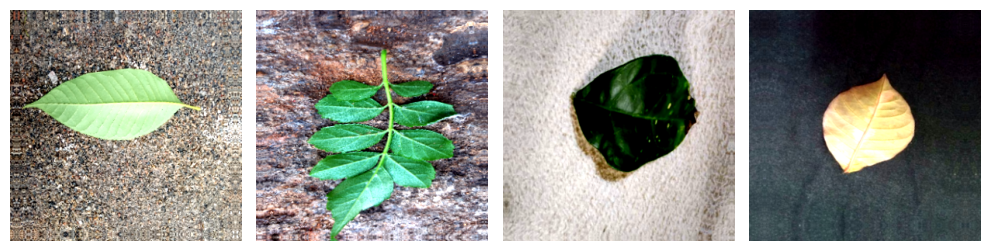

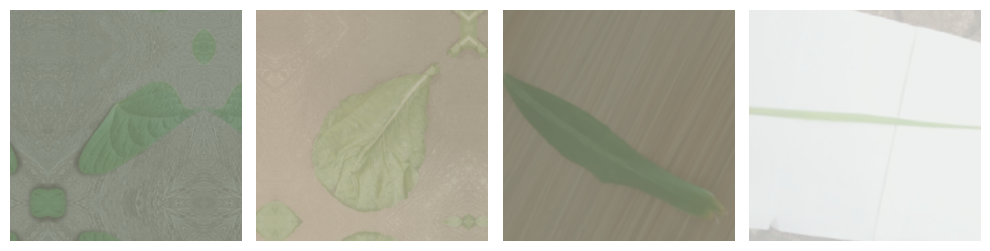

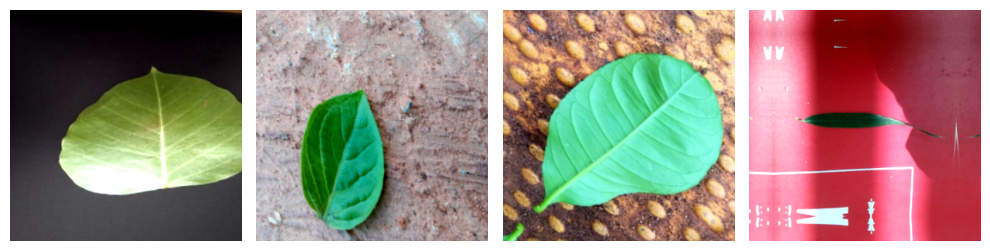

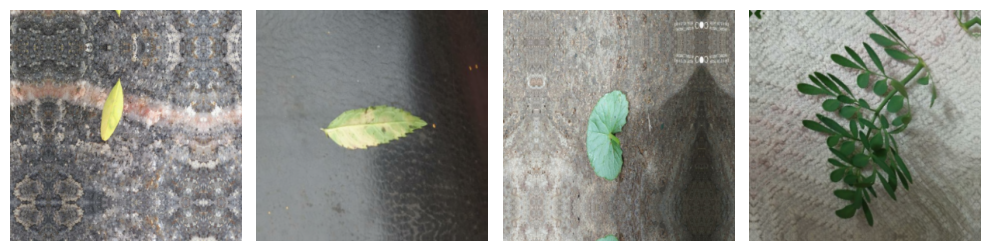

In [ ]:
# Function to plot images with labels
def plot_images_with_labels(images, labels, class_names):
    plt.figure(figsize=(10, 10))
    for i in range(4):  
        ax = plt.subplot(4, 4, i + 1)
        plt.imshow(images[i])
        #plt.title(class_names[labels[i]]) 
        plt.axis("off")
    plt.tight_layout()
    plt.show()

# Get the class names from the dataset

print(len(train_data))
# Extract one batch of images and labels
for images, labels in train_data.take(5):
    images = images.numpy()
    labels = labels.numpy()

    # Plot the images with their corresponding labels
    plot_images_with_labels(images, labels, class_names)

# **Preparing the model**

In [8]:
base_model = tf.keras.applications.inception_v3.InceptionV3(
    include_top=False,
    weights="imagenet",
    input_shape = (299, 299, 3)
)


87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [9]:
for layer in base_model.layers[:290]:
  layer.trainable = False
for layer in base_model.layers[290:]:
  layer.trainable = True
base_model.summary()

Model: "inception_v3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1             │ (None, 299, 299, 3)    │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d (Conv2D)           │ (None, 149, 149, 32)   │            864 │ input_layer_1[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization       │ (None, 149, 149, 32)   │             96 │ conv2d[0][0]           │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ activation (Activation)   │ (None, 149, 149, 32)   │              0 │ batch_normalization[0… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_1 (Conv2D)         │ (None, 147, 147, 32)   │          9,216 │ activation[0][0]       │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_1     │ (None, 147, 147, 32)   │             96 │ conv2d_1[0][0]         │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ activation_1 (Activation) │ (None, 147, 147, 32)   │              0 │ batch_normalization_1… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_2 (Conv2D)         │ (None, 147, 147, 64)   │         18,432 │ activation_1[0][0]     │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_2     │ (None, 147, 147, 64)   │            192 │ conv2d_2[0][0]         │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ activation_2 (Activation) │ (None, 147, 147, 64)   │              0 │ batch_normalization_2… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d             │ (None, 73, 73, 64)     │              0 │ activation_2[0][0]     │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_3 (Conv2D)         │ (None, 73, 73, 80)     │          5,120 │ max_pooling2d[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_3     │ (None, 73, 73, 80)     │            240 │ conv2d_3[0][0]         │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ activation_3 (Activation) │ (None, 73, 73, 80)     │              0 │ batch_normalization_3… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_4 (Conv2D)         │ (None, 71, 71, 192)    │        138,240 │ activation_3[0][0]     │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_4     │ (None, 71, 71, 192)    │            576 │ conv2d_4[0][0]         │
│ (BatchNormalization)      │                        │                │                        │
├──────────────────────

 Total params: 21,802,784 (83.17 MB)

 Trainable params: 2,377,728 (9.07 MB)

 Non-trainable params: 19,425,056 (74.10 MB)

In [10]:
filepath = "model_{epoch:02d}-{val_accuracy:.2f}.h5"
checkpoint1 = ModelCheckpoint(filepath, monitor='val_accuracy', verbose=1, save_best_only=True, mode='max')

callbacks_list = [
    tf.keras.callbacks.ModelCheckpoint(
        filepath='model.keras',
        monitor='val_loss', save_best_only=True, verbose=1),
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=50,verbose=1),
    checkpoint1
]

In [11]:
from keras.layers import Dense, Input, Flatten, Dropout, GlobalAveragePooling2D
from tensorflow.keras.models import Model

x = GlobalAveragePooling2D()(base_model.output)
x = Dense(512, activation='relu')(x)
x = Dropout(0.5)(x)  # 50% of nodes are randomly dropped during training
x = Dense(256, activation='relu')(x)
x = Dropout(0.3)(x)
output = Dense(80, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)

In [ ]:
model.summary()

In [13]:
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

In [ ]:
history = model.fit(train_data, validation_data=test_data,callbacks=callbacks_list, epochs=epoches)

In [ ]:
import pickle
with open('trainHistoryDict.txt', 'wb') as file_pi:
    pickle.dump(history.history, file_pi)